In [1]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a clean presentation
warnings.filterwarnings('ignore')

print("--- Phase 1: Data Acquisition ---")

# Load the dataset
df = pd.read_csv('phishing_site_urls.csv')

# Standardize labels: 'good' -> 0 (Safe), 'bad' -> 1 (Phishing)
if df['Label'].dtype == 'O': 
    df['Label'] = df['Label'].map({'good': 0, 'bad': 1})

# Take a working sample
df_sample = df.sample(n=10000, random_state=42).copy()

print(f"[INFO] Dataset loaded successfully.")
print(f"[INFO] Working sample size: {len(df_sample)} records.")

--- Phase 1: Data Acquisition ---
[INFO] Dataset loaded successfully.
[INFO] Working sample size: 10000 records.


--- Phase 2: Exploratory Data Analysis (EDA) ---


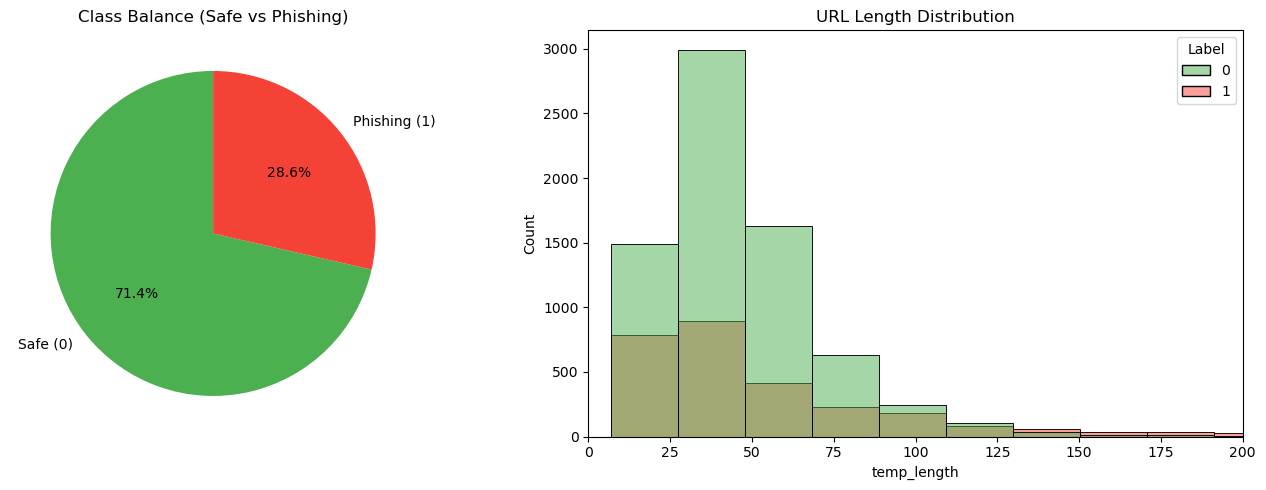

In [2]:
print("--- Phase 2: Exploratory Data Analysis (EDA) ---")

# Create a temporary column just for the EDA plot
df_sample['temp_length'] = df_sample['URL'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Label Distribution (Pie Chart)
labels = ['Safe (0)', 'Phishing (1)']
sizes = df_sample['Label'].value_counts()
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#4CAF50', '#F44336'])
axes[0].set_title('Class Balance (Safe vs Phishing)')

# 2. URL Length Histogram
sns.histplot(data=df_sample, x='temp_length', hue='Label', bins=50, ax=axes[1], palette=['#4CAF50', '#F44336'])
axes[1].set_title('URL Length Distribution')
axes[1].set_xlim(0, 200) 

plt.tight_layout()
plt.show()

# Clean up temporary column
df_sample.drop(columns=['temp_length'], inplace=True)

In [3]:
print("--- Phase 3: Lexical Feature Engineering ---")

def extract_features(url):
    try:
        if not url.startswith('http'):
            url = 'http://' + url
            
        parsed_url = urlparse(url)
        domain = parsed_url.netloc
        
        url_length = len(url)
        domain_length = len(domain)
        num_dots = url.count('.')
        num_hyphens = url.count('-')
        num_at_symbols = url.count('@')
        num_slashes = url.count('/')
        num_digits = sum(c.isdigit() for c in url)
        has_https = 1 if parsed_url.scheme == 'https' else 0
        has_ip = 1 if re.match(r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$", domain) else 0
        
        return [url_length, domain_length, num_dots, num_hyphens, num_at_symbols, num_slashes, num_digits, has_https, has_ip]
    except:
        return [0, 0, 0, 0, 0, 0, 0, 0, 0]

feature_columns = ['url_length', 'domain_length', 'num_dots', 'num_hyphens', 'num_at_symbols', 'num_slashes', 'num_digits', 'has_https', 'has_ip']

print("[INFO] Parsing URLs and extracting numerical features...")
features_list = df_sample['URL'].apply(extract_features).tolist()
X = pd.DataFrame(features_list, columns=feature_columns)
y = df_sample['Label'].values

print("[INFO] Feature matrix constructed.")
display(X.head(3))

--- Phase 3: Lexical Feature Engineering ---
[INFO] Parsing URLs and extracting numerical features...
[INFO] Feature matrix constructed.


,url_length,domain_length,num_dots,num_hyphens,num_at_symbols,num_slashes,num_digits,has_https,has_ip
0,37,14,1,0,0,4,0,0,0
1,83,14,1,0,0,5,11,0,0
2,71,9,2,0,0,6,15,0,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- Phase 4: Data Preprocessing ---")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"[INFO] Data split: {X_train.shape[0]} training samples, {X_test.shape[0]} testing samples.")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("[INFO] Data standardized using StandardScaler.")

--- Phase 4: Data Preprocessing ---
[INFO] Data split: 8000 training samples, 2000 testing samples.
[INFO] Data standardized using StandardScaler.


In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("--- Phase 5: Model Stability Testing (5-Fold CV) ---")

# Test Baseline
cv_log = cross_val_score(LogisticRegression(max_iter=1000, random_state=42), X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Logistic Regression CV Accuracy: {cv_log.mean():.4f} (+/- {cv_log.std() * 2:.4f})")

# Test Ensemble
cv_rf = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Random Forest CV Accuracy:     {cv_rf.mean():.4f} (+/- {cv_rf.std() * 2:.4f})")
print("[INFO] Cross-validation complete. Variances are low, indicating stable models.")

--- Phase 5: Model Stability Testing (5-Fold CV) ---
Logistic Regression CV Accuracy: 0.7731 (+/- 0.0122)
Random Forest CV Accuracy:     0.8234 (+/- 0.0190)
[INFO] Cross-validation complete. Variances are low, indicating stable models.


--- Phase 6: Model Training & Confusion Matrices ---


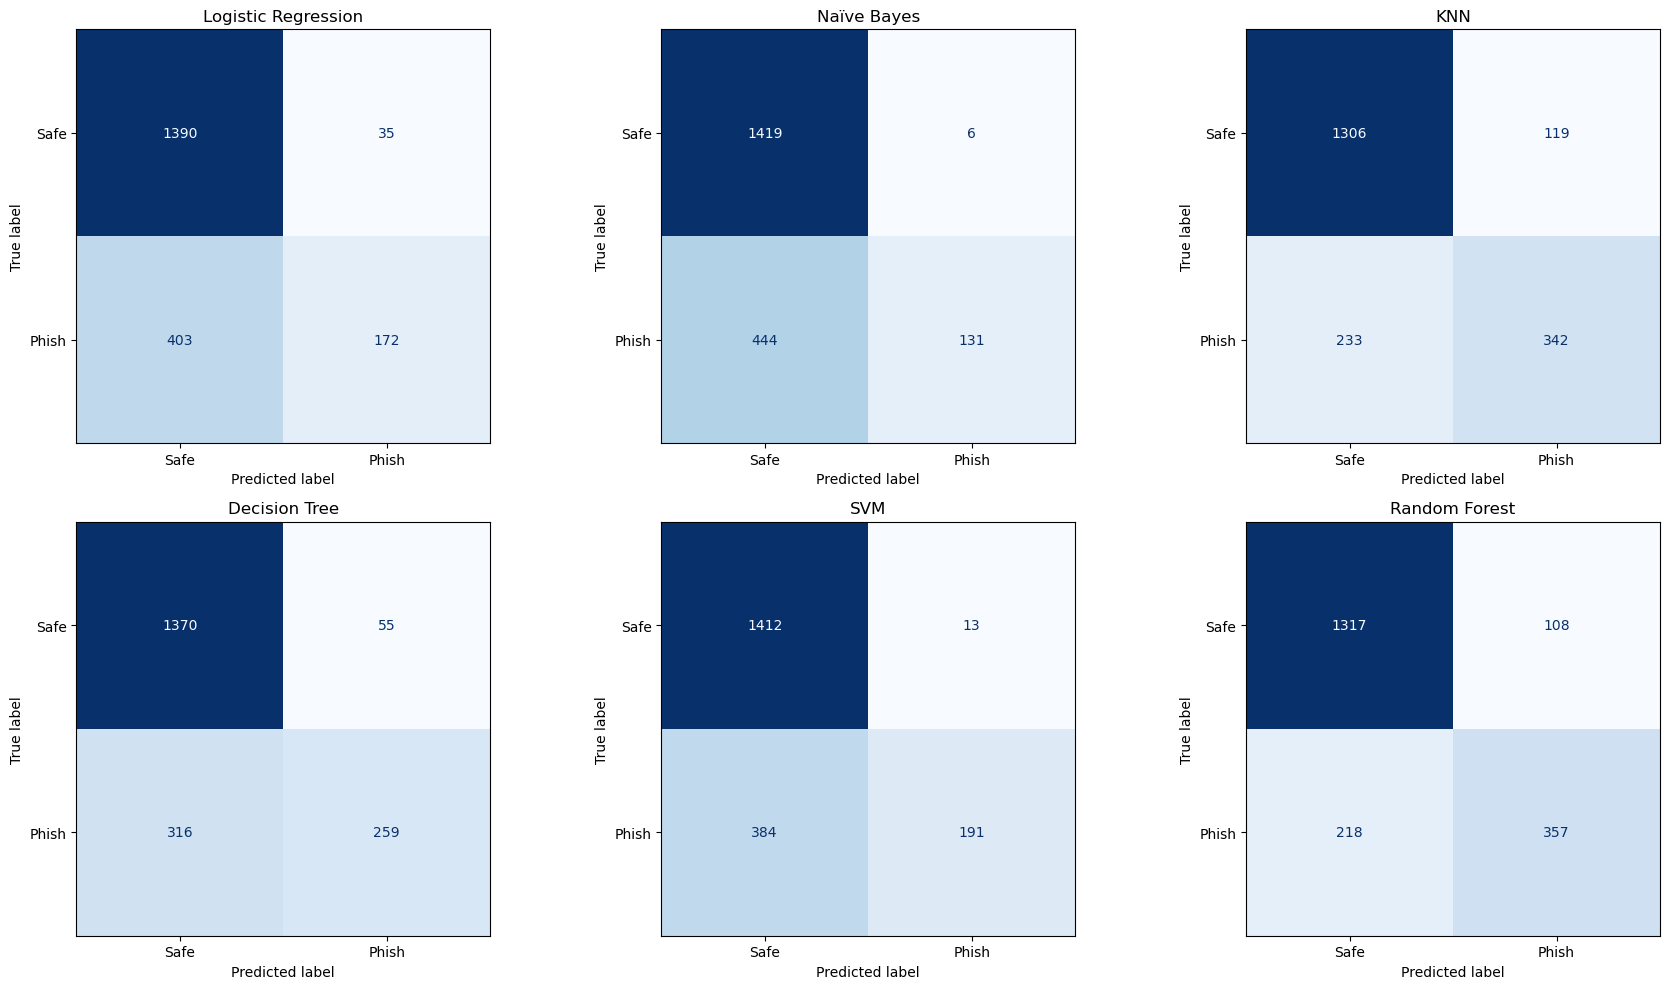

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

print("--- Phase 6: Model Training & Confusion Matrices ---")

# Notice probability=True is added to SVC for the ROC curve later
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naïve Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    y_pred = model.predict(X_test_scaled)
    
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Safe', 'Phish'], cmap='Blues', ax=axes[idx], colorbar=False
    )
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("--- Phase 8: Comprehensive Model Evaluation ---")

comparison_data = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

df_compare = pd.DataFrame(comparison_data).sort_values(by="F1-Score", ascending=False)
display(df_compare.style.background_gradient(cmap='Blues'))

--- Phase 8: Comprehensive Model Evaluation ---


,Model,Accuracy,Precision,Recall,F1-Score
5,Random Forest,0.837000,0.767742,0.620870,0.686538
2,KNN,0.824000,0.741866,0.594783,0.660232
3,Decision Tree,0.814500,0.824841,0.450435,0.582677
4,SVM,0.801500,0.936275,0.332174,0.490372
0,Logistic Regression,0.781000,0.830918,0.299130,0.439898
1,Naïve Bayes,0.775000,0.956204,0.227826,0.367978


--- Phase 7: ROC Curve & AUC Analysis ---


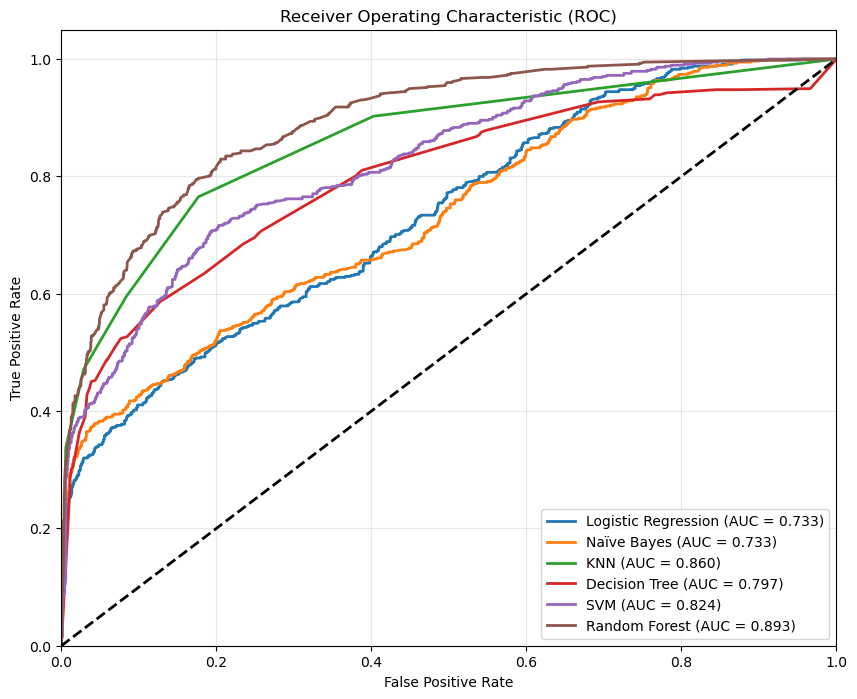

In [10]:
from sklearn.metrics import roc_curve, auc

print("--- Phase 7: ROC Curve & AUC Analysis ---")

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    # Get prediction probabilities for class 1 (Phishing)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

--- Phase 9: Model Interpretability ---


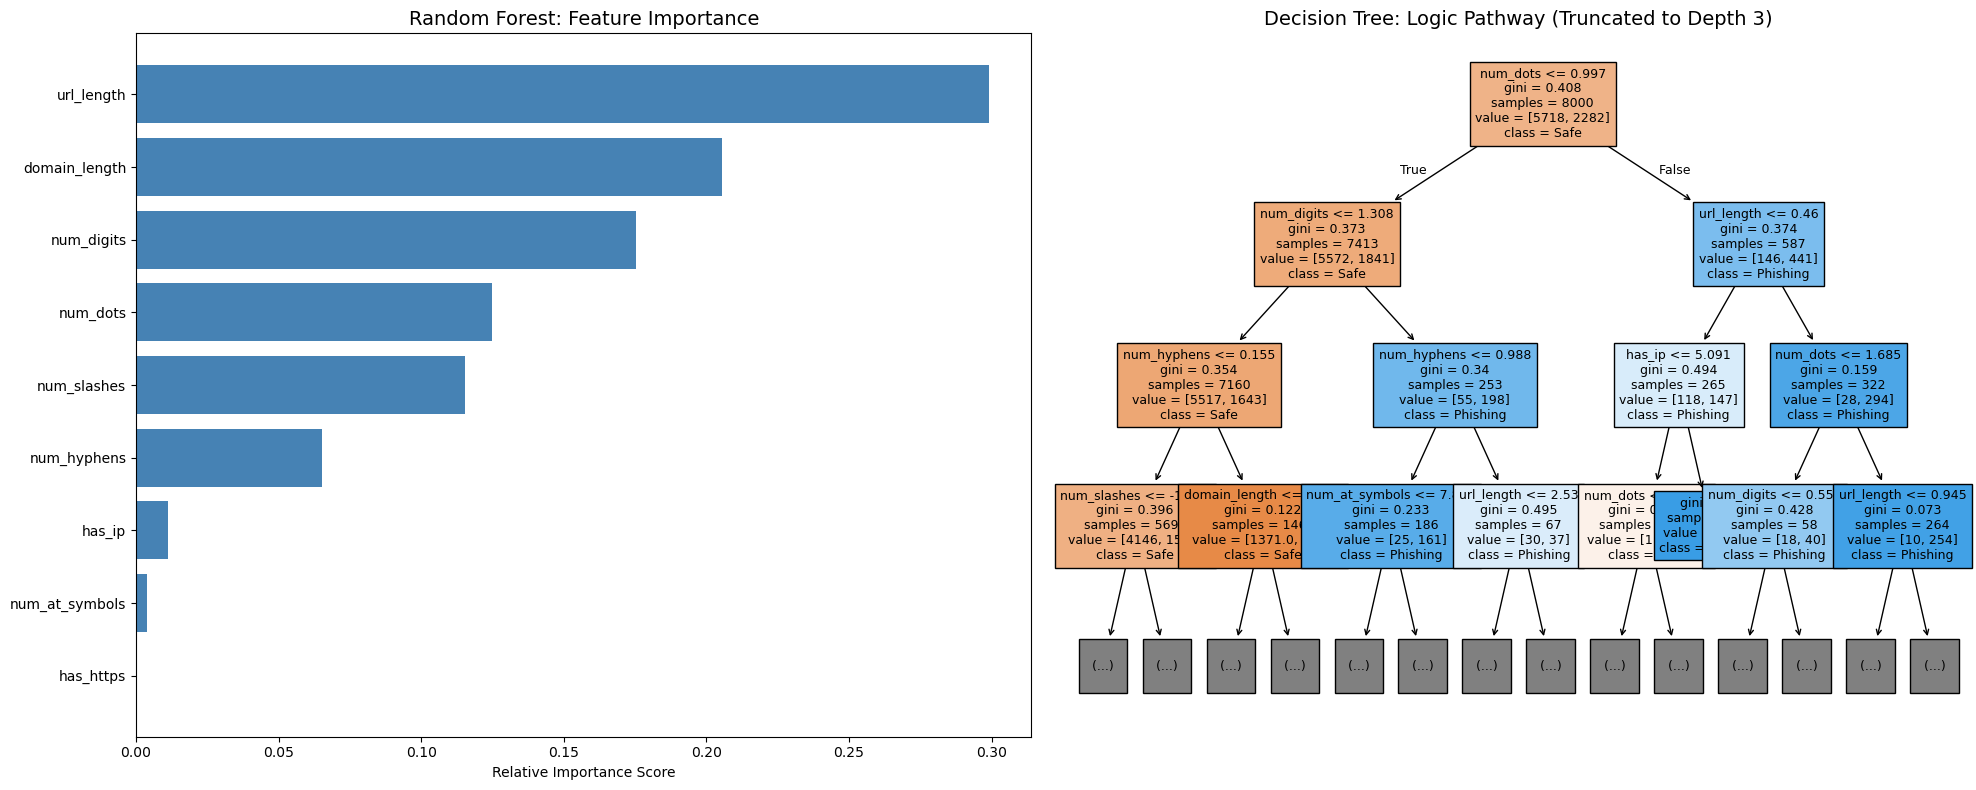

In [11]:
from sklearn.tree import plot_tree

print("--- Phase 9: Model Interpretability ---")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Feature Importance (from Random Forest)
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_
df_importance = pd.DataFrame({'Feature': feature_columns, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=True)

axes[0].barh(df_importance['Feature'], df_importance['Importance'], color='steelblue')
axes[0].set_title('Random Forest: Feature Importance', fontsize=14)
axes[0].set_xlabel('Relative Importance Score')

# 2. Decision Tree Visualization (Plotting the standalone Decision Tree up to depth 3)
dt_model = trained_models["Decision Tree"]
plot_tree(dt_model, max_depth=3, feature_names=feature_columns, class_names=['Safe', 'Phishing'], 
          filled=True, ax=axes[1], fontsize=9)
axes[1].set_title('Decision Tree: Logic Pathway (Truncated to Depth 3)', fontsize=14)

plt.tight_layout()
plt.show()

In [14]:
import joblib

print("--- Phase 10: Model Serialization ---")

best_model_name = df_compare.iloc[0]['Model']
best_model_instance = trained_models[best_model_name]

joblib.dump(best_model_instance, 'phishing_production_model.pkl')
joblib.dump(scaler, 'url_production_scaler.pkl')

print(f"[INFO] Optimal Model which is {best_model_name} serialized to disk.")
print("[INFO] Feature scaling parameters saved.")
print("[INFO] Pipeline ready for production deployment.")

--- Phase 10: Model Serialization ---
[INFO] Optimal Model which is Random Forest serialized to disk.
[INFO] Feature scaling parameters saved.
[INFO] Pipeline ready for production deployment.
